In [ ]:
import pandas as pd
import sqlite3
#reading the csv file
data = pd.read_csv('./India_Menu.csv')
#creating a connection to the SQLite database
conn = sqlite3.connect('MacDonald.db')
#writing the data to a table named 'nutrition' in the database
data.to_sql('nutrition', conn, if_exists='replace', index=False)
#reading the data back from the database to verify
df = pd.read_sql("SELECT * FROM nutrition", conn)
print(df.head())

  Menu Category              Menu Items Per Serve Size  Energy (kCal)  \
0  Regular Menu        McVeggie™ Burger          168 g         402.05   
1  Regular Menu    McAloo Tikki Burger®          146 g         339.52   
2  Regular Menu  McSpicy™ Paneer Burger          199 g         652.76   
3  Regular Menu       Spicy Paneer Wrap          250 g         674.68   
4  Regular Menu     American Veg Burger          177 g         512.17   

   Protein (g)  Total fat (g)  Sat Fat (g)  Trans fat (g)  Cholesterols (mg)  \
0        10.24          13.83         5.34           0.16               2.49   
1         8.50          11.31         4.27           0.20               1.47   
2        20.29          39.45        17.12           0.18              21.85   
3        20.96          39.10        19.73           0.26              40.93   
4        15.30          23.45        10.51           0.17              25.24   

   Total carbohydrate (g)  Total Sugars (g)  Added Sugars (g)  Sodium (mg)  
0  

In [2]:
df.describe(include='all')  # Display summary statistics for all columns

,Menu Category,Menu Items,Per Serve Size,Energy (kCal),Protein (g),Total fat (g),Sat Fat (g),Trans fat (g),Cholesterols (mg),Total carbohydrate (g),Total Sugars (g),Added Sugars (g),Sodium (mg)
count,141,141,141,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,140.000000
unique,7,141,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,McCafe Menu,McVeggie™ Burger,299 ml,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,51,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,244.635461,7.493546,9.991702,4.997589,0.687163,26.350071,31.190284,15.464894,10.336950,362.064143
std,NaN,NaN,NaN,185.554837,8.336863,10.339511,4.900451,6.326136,50.334200,20.602044,15.690202,14.283388,473.160490
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,116.360000,0.650000,0.460000,0.280000,0.060000,1.510000,15.740000,2.330000,0.000000,43.895000
50%,NaN,NaN,NaN,219.360000,4.790000,7.770000,4.270000,0.150000,8.390000,30.820000,9.160000,3.640000,152.025000
75%,NaN,NaN,NaN,339.520000,10.880000,14.160000,7.280000,0.220000,31.110000,46.000000,26.950000,19.230000,534.240000


c:\Users\evanr\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 27.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\evanr\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\evanr\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 37.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\evanr\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(ms

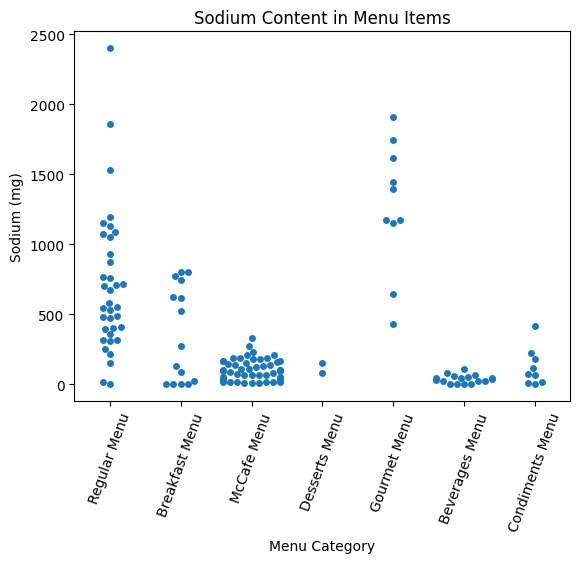

In [ ]:
#let's find the sodium content of the food items and plot the results using matplotlib, seaborn, and plotly
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
#plotting the sodium content using categorical scatter plot. Ignore if the sodium content is not available
sns.swarmplot(x='Menu Category', y='Sodium (mg)', data=df)
plt.xticks(rotation=70)
plt.title('Sodium Content in Menu Items')
plt.show()

In [16]:
# Display summary statistics for sodium content
sodium_stats = df['Sodium (mg)'].describe()
print(sodium_stats)

count     140.000000
mean      362.064143
std       473.160490
min         0.000000
25%        43.895000
50%       152.025000
75%       534.240000
max      2399.490000
Name: Sodium (mg), dtype: float64


In [17]:
# Find the food item with the highest sodium content
#finding the index of the food item with the highest sodium content
df['Sodium (mg)'].idxmax()

18

In [20]:
df.at[18, 'Menu Items']  # Display the food item with the highest sodium content using the index


'Ghee Rice with Mc Spicy Fried Chicken 1 pc'

<Figure size 2000x600 with 0 Axes>

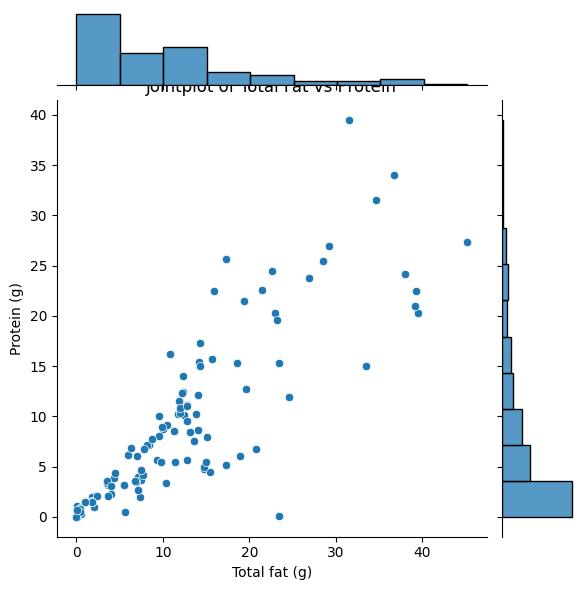

In [25]:
# EDA using jointplot for total fat and protein content
#defining the plot area so that it can be fitted properly
%matplotlib inline
import seaborn as sns
plt.figure(figsize=(20, 6))
sns.jointplot(x='Total fat (g)', y='Protein (g)', data=df, kind='scatter')
plt.title('Jointplot of Total Fat vs Protein')
plt.show()

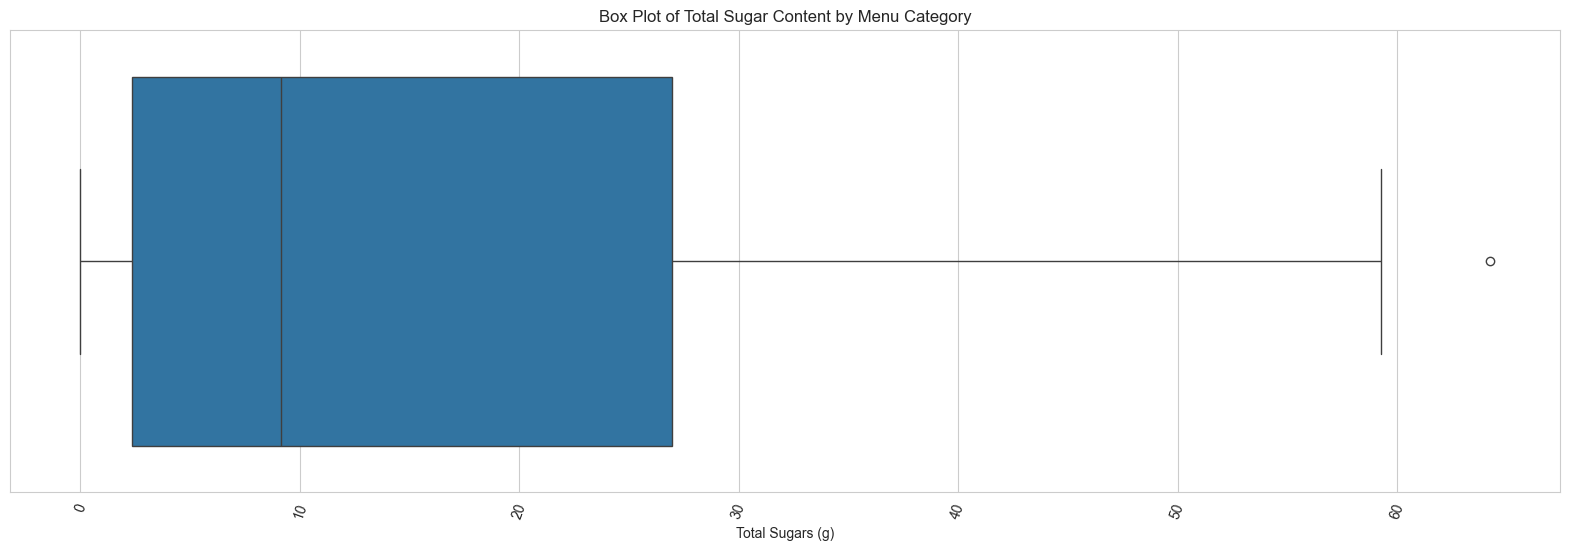

In [28]:
# now lets do a box plot for total sugar
plt.figure(figsize=(20, 6))
sns.set_style("whitegrid")
sns.boxplot(x=df["Total Sugars (g)"])
plt.xticks(rotation=70)
plt.title('Box Plot of Total Sugar Content by Menu Category')
plt.show()